In [ ]:
# tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun, WolframAlphaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

api_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
api_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)

arxiv_tool = ArxivQueryRun(
    api_wrapper=api_arxiv, 
    description="Useful for searching for academic papers on arXiv. Input should be a search query."
    )
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=api_wikipedia, 
    description="Useful for searching for information on Wikipedia. Input should be a search query."
)

In [5]:
arxiv_tool.invoke("What are the latest papers on deep learning?")

'Published: 2023-01-03\nTitle: Deep Learning and Computational Physics (Lecture Notes)\nAuthors: Deep Ray, Orazio Pinti, Assad A. Oberai\nSummary: These notes were compiled as lecture notes for a course developed and taught at the University of the Southern California. They should be accessible to a typical engineering graduate student with a strong background in Applied Mathematics.\n  The main objective of these notes is to introduce a student who is familiar with concepts in linear algebra and par'

In [7]:
wikipedia_tool.invoke("What is attention?")

'Page: Attention Is All You Need\nSummary: "Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence, including large language models. At the time, the focus of'

In [8]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [ ]:
# tavily search tool 
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch()

In [12]:
tavily_tool.invoke("What are the latest news on AI?")

[{'title': 'Google AI announcements from March',
  'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-march-2026/',
  'content': 'Learn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\nLearn more:\n\n# The latest AI news we announced in March 2026\n\nApr 01, 2026\n\nHere’s a recap of our biggest AI updates from March 2026, including an expansion of Search Live, more ways to access Personal Intelligence and new tools that make it easier to switch to Gemini.\n\n## General summary\n\nIn March, Google focused on making AI more helpful in your daily life with updates to Gemini. These updates help Gemini understand your context, turning devices into proactive helpers for work, creativity, and intuitive living. New features include expanded Search Live, enhanced AI tools in Docs, Sheets, Slides, and Drive, Google Maps upgrades, Personal Intelligence expansion, and tools to switch to Gemini. [...] ## Bullet points\n\n "The latest AI news we announ

In [13]:
tools = [arxiv_tool, wikipedia_tool, tavily_tool]

In [14]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm.invoke("what is AI?")

AIMessage(content='<think>\nOkay, the user is asking, "What is AI?" I need to explain this clearly. Let me start by breaking down the term.\n\nAI stands for Artificial Intelligence. So first, I should define what that means. Artificial Intelligence is the simulation of human intelligence in machines. But how do I explain that in a way that\'s easy to understand?\n\nMaybe start with the basics. Mention that AI systems are designed to perform tasks that usually require human intelligence. But what tasks? Examples like problem-solving, learning, language understanding, and perception come to mind. I should list some of these to make it concrete.\n\nWait, there are different types of AI. I remember there\'s narrow AI and general AI. Narrow AI is what we see today, like voice assistants or recommendation systems. General AI is more like human-level intelligence, which we haven\'t achieved yet. I should explain the distinction but keep it simple.\n\nHow does AI work? Machine learning is a bi

In [16]:
llm_with_tools = llm.bind_tools(tools)

llm_with_tools.invoke("What are the latest news on AI and what are the latest papers on deep learning?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the latest news on AI and the latest papers on deep learning. Let me break this down.\n\nFirst, for the latest news, I should use a search engine that can fetch current events. The available tools include Tavily Search, which is described as optimized for comprehensive and accurate results, especially for current events. So I\'ll use that with a query like "latest news on AI".\n\nNext, for the latest papers on deep learning, the arXiv function is the right choice since it\'s for academic papers. The query here would be something like "latest deep learning papers" or maybe "recent advances in deep learning" to get the most relevant results.\n\nI need to make sure I call both functions. The user wants both pieces of information, so I should execute two separate tool calls. Let me check the parameters again to ensure they\'re correct. The Tavily Search takes a query string, and arXiv also takes a q

In [17]:
llm_with_tools.invoke("What are the latest research papers on deep learning?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the latest research papers on deep learning. I need to figure out which tool to use here. The available tools are arXiv, Wikipedia, and Tavily Search. \n\nArXiv is specifically for academic papers, so that seems like the best fit. The user wants research papers, so using the arXiv function makes sense. The query parameter should be "deep learning" to get relevant results.\n\nI should check if there are any other tools that might be better, but Tavily is for current events and Wikipedia for general info. Since the user is asking about research papers, arXiv is definitely the right choice. \n\nI need to structure the tool call with the function name "arxiv" and the arguments as a JSON object with the query. Let me make sure the parameters are correctly formatted. The required parameter is "query" of type string. \n\nSo the tool call should look like {"name": "arxiv", "arguments": {"query": "deep l

In [18]:
llm_with_tools.invoke("What is deep learning?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is deep learning?" I need to provide a clear and accurate explanation. Let me start by recalling my existing knowledge. Deep learning is a subset of machine learning that uses neural networks with many layers to model complex patterns in data. It\'s widely used in image recognition, natural language processing, and other areas.\n\nBut I should verify if there\'s any recent development or a more precise definition. Maybe check Wikipedia for the standard definition. Also, arXiv might have recent papers that discuss deep learning techniques. However, since the user is asking for a basic definition, Wikipedia might be sufficient. Let me use the wikipedia function to look up "Deep learning" to get the most accurate and concise information. That should cover the key points without needing to delve into arXiv papers unless there\'s a need for more technical details. Alright, let\'s proceed with the W

In [21]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

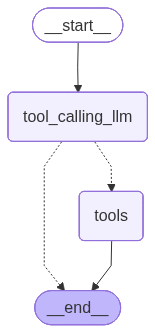

In [24]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition 

def tool_calling_llm(state: State) -> str:
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))


builder.add_edge(START, "tool_calling_llm")
builder .add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages = graph.invoke({"messages":"1706.03762"})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (f71y98ed2)
 Call ID: f71y98ed2
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [27]:
messages = graph.invoke({"messages":"my name is khaled "})
for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

my name is khaled 
================================== Ai Message ==================================

Nice to meet you, Khaled! How can I help you today?
